In [ ]:
# Built-ins
import os
from pathlib import Path

# Data science / utilities
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mode

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# HMM
from hmmlearn.hmm import GaussianHMM

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    TimeDistributed,
    GlobalAveragePooling2D,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# KAN custom layers (external package)
from tfkan.layers import Conv2DKAN, DenseKAN

In [24]:
base_path = 'D:\MobileLSTM-HMM-KAN\dataset\\ff23'
categories = ['fake', 'real']

# Initialize a list to hold data
data = []

# Process each category
for category in categories:
    category_path = os.path.join(base_path, category)
    for filename in os.listdir(category_path):
        if filename.endswith('.jpg'):
            try:
                id_part, frame_part = filename.split('_frame_')
                id_ = id_part.split('_')[0]
                frame = frame_part.split('.')[0]
                data.append({
                    'filename': filename,
                    'path': os.path.join(category_path, filename),
                    'id': int(id_),
                    'frame': int(frame),
                    'label': category
                })
            except ValueError:
                continue

# Convert the data to a DataFrame
df = pd.DataFrame(data)
df['label_id'] = df['label'].map({'fake': 0, 'real': 1})
df.head()

,filename,path,id,frame,label,label_id
0,000_003_frame_0000.jpg,D:\MobileLSTM-HMM-KAN\dataset\ff23\fake\000_00...,0,0,fake,0
1,000_003_frame_0001.jpg,D:\MobileLSTM-HMM-KAN\dataset\ff23\fake\000_00...,0,1,fake,0
2,000_003_frame_0002.jpg,D:\MobileLSTM-HMM-KAN\dataset\ff23\fake\000_00...,0,2,fake,0
3,000_003_frame_0003.jpg,D:\MobileLSTM-HMM-KAN\dataset\ff23\fake\000_00...,0,3,fake,0
4,000_003_frame_0004.jpg,D:\MobileLSTM-HMM-KAN\dataset\ff23\fake\000_00...,0,4,fake,0


In [25]:
df['video_key'] = df['id'].astype(str) + "_" + df['label']

from collections import defaultdict

video_dict = defaultdict(list)
labels = {}

for _, row in df.iterrows():
    key = row['video_key']
    video_dict[key].append(row['path'])
    labels[key] = row['label_id']


In [ ]:
video_keys = list(video_dict.keys())
video_labels = [labels[k] for k in video_keys]

img_size = (224, 224)
batch_size = 32
epochs = 50
n_splits = 5
sequence_len = 10
results = []
all_histories = []

# Data generator
class VideoSequence(tf.keras.utils.Sequence):
    def __init__(self, video_keys, video_dict, labels, batch_size, img_size, sequence_len=10, augment=False):
        self.video_keys = video_keys
        self.video_dict = video_dict
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.sequence_len = sequence_len
        self.augment = augment
        self.datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=15 if augment else 0,
            zoom_range=0.1 if augment else 0,
            horizontal_flip=augment
        )

    def __len__(self):
        return int(np.ceil(len(self.video_keys) / self.batch_size))

    def __getitem__(self, idx):
        batch_keys = self.video_keys[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_X, batch_y = [], []

        for key in batch_keys:
            frames = self.video_dict[key][:self.sequence_len]
            imgs = []
            for path in frames:
                img = cv2.imread(path)
                img = cv2.resize(img, self.img_size)
                img = self.datagen.random_transform(img) if self.augment else img
                img = img.astype('float32') / 255.0
                imgs.append(img)
            while len(imgs) < self.sequence_len:
                imgs.append(np.zeros((*self.img_size, 3), dtype='float32'))
            batch_X.append(imgs)
            batch_y.append(self.labels[key])

        return np.array(batch_X), np.array(batch_y)

# Build model cải tiến
def build_model(sequence_len, img_size):

    # Freeze toàn bộ backbone để giảm overfit
    base_cnn.trainable = False

    # CNN feature extractor
    cnn_out = GlobalAveragePooling2D()(base_cnn.output)
    cnn_model = Model(inputs=base_cnn.input, outputs=cnn_out)

    # Sequence input
    input_seq = Input(shape=(sequence_len, *img_size, 3))
    x = TimeDistributed(cnn_model)(input_seq)

    # Temporal modeling
    x = LSTM(64, return_sequences=False)(x)
    x = Dropout(0.5)(x)

    # Classification
    x = DenseKAN(1)(x)
    output = tf.keras.activations.sigmoid(x)

    model = Model(inputs=input_seq, outputs=output)
    return model

# HMM cải tiến
def hmm_postprocess(pred_probs, y_true, n_states=2):
    pred_probs = pred_probs.reshape(-1, 1)
    hmm = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=100)
    hmm.fit(pred_probs)
    hidden_states = hmm.predict(pred_probs)

    mapping = {}
    for state in np.unique(hidden_states):
        indices = [i for i in range(len(hidden_states)) if hidden_states[i] == state]
        state_labels = [y_true[i] for i in indices]
        if len(state_labels) > 0:
            mapped_label = mode(state_labels, keepdims=True).mode[0]
        else:
            mapped_label = 0  # fallback
        mapping[state] = mapped_label

    hmm_labels = np.array([mapping[s] for s in hidden_states])
    return hmm_labels

# Training K-Fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (trainval_idx, test_idx) in enumerate(skf.split(video_keys, video_labels), 1):
    print(f"\n===== Fold {fold} =====")

    trainval_keys = [video_keys[i] for i in trainval_idx]
    test_keys = [video_keys[i] for i in test_idx]

    y_trainval = [labels[k] for k in trainval_keys]
    train_keys, val_keys = train_test_split(trainval_keys, test_size=0.1, stratify=y_trainval, random_state=fold)

    train_gen = VideoSequence(train_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=True)
    val_gen = VideoSequence(val_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)
    test_gen = VideoSequence(test_keys, video_dict, labels, batch_size, img_size, sequence_len, augment=False)

    model = build_model(sequence_len, img_size)
    model.compile(optimizer=Adamax(1e-4), loss='binary_crossentropy', metrics=['accuracy'])

    model_path = f"best_model_fold{fold}.h5"
    checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    earlystop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs,
                        callbacks=[checkpoint, earlystop, reduce_lr], verbose=1)
    all_histories.append(history.history)

    model.load_weights(model_path)

    y_true = [labels[k] for k in test_keys]
    y_pred_prob = model.predict(test_gen).ravel()
    y_hmm_pred = hmm_postprocess(y_pred_prob, y_true)

    results.append({
        'fold': fold,
        'accuracy': accuracy_score(y_true, y_hmm_pred),
        'precision': precision_score(y_true, y_hmm_pred),
        'recall': recall_score(y_true, y_hmm_pred),
        'f1': f1_score(y_true, y_hmm_pred),
        'auc': roc_auc_score(y_true, y_pred_prob)
    })

print("\n📊 Tổng kết kết quả các fold:")
for r in results:
    print(f"Fold {r['fold']}: Accuracy={r['accuracy']:.4f}, F1={r['f1']:.4f}, AUC={r['auc']:.4f}")



===== Fold 1 =====


9406464/9406464 [==============================] - 2s 0us/step
Epoch 1/50


45/45 [==============================] - ETA: 0s - loss: 0.6976 - accuracy: 0.5201
Epoch 1: val_accuracy improved from -inf to 0.54375, saving model to best_model_fold1.h5


d:\MobileLSTM-HMM-KAN\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


45/45 [==============================] - 394s 9s/step - loss: 0.6976 - accuracy: 0.5201 - val_loss: 0.6897 - val_accuracy: 0.5437 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6804 - accuracy: 0.5556
Epoch 2: val_accuracy improved from 0.54375 to 0.56875, saving model to best_model_fold1.h5
45/45 [==============================] - 144s 3s/step - loss: 0.6804 - accuracy: 0.5556 - val_loss: 0.6827 - val_accuracy: 0.5688 - lr: 1.0000e-04
Epoch 3/50
45/45 [==============================] - ETA: 0s - loss: 0.6608 - accuracy: 0.6083
Epoch 3: val_accuracy improved from 0.56875 to 0.58750, saving model to best_model_fold1.h5
45/45 [==============================] - 134s 3s/step - loss: 0.6608 - accuracy: 0.6083 - val_loss: 0.6741 - val_accuracy: 0.5875 - lr: 1.0000e-04
Epoch 4/50
45/45 [==============================] - ETA: 0s - loss: 0.6580 - accuracy: 0.6021
Epoch 4: val_accuracy did not improve from 0.58750
45/45 [==============================] - 1

d:\MobileLSTM-HMM-KAN\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


45/45 [==============================] - 140s 3s/step - loss: 0.6897 - accuracy: 0.5368 - val_loss: 0.6667 - val_accuracy: 0.6812 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6736 - accuracy: 0.5882
Epoch 2: val_accuracy improved from 0.68125 to 0.72500, saving model to best_model_fold2.h5
45/45 [==============================] - 143s 3s/step - loss: 0.6736 - accuracy: 0.5882 - val_loss: 0.6515 - val_accuracy: 0.7250 - lr: 1.0000e-04
Epoch 3/50
45/45 [==============================] - ETA: 0s - loss: 0.6552 - accuracy: 0.6285
Epoch 3: val_accuracy did not improve from 0.72500
45/45 [==============================] - 175s 4s/step - loss: 0.6552 - accuracy: 0.6285 - val_loss: 0.6389 - val_accuracy: 0.6875 - lr: 1.0000e-04
Epoch 4/50
45/45 [==============================] - ETA: 0s - loss: 0.6391 - accuracy: 0.6535
Epoch 4: val_accuracy did not improve from 0.72500
45/45 [==============================] - 177s 4s/step - loss: 0.6391 - accuracy: 0.

...

45/45 [==============================] - 191s 4s/step - loss: 0.6990 - accuracy: 0.5285 - val_loss: 0.6621 - val_accuracy: 0.6187 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6740 - accuracy: 0.5819
Epoch 2: val_accuracy improved from 0.61875 to 0.66875, saving model to best_model_fold3.h5
45/45 [==============================] - 152s 3s/step - loss: 0.6740 - accuracy: 0.5819 - val_loss: 0.6520 - val_accuracy: 0.6687 - lr: 1.0000e-04
Epoch 3/50
45/45 [==============================] - ETA: 0s - loss: 0.6646 - accuracy: 0.6028
Epoch 3: val_accuracy did not improve from 0.66875
45/45 [==============================] - 152s 3s/step - loss: 0.6646 - accuracy: 0.6028 - val_loss: 0.6428 - val_accuracy: 0.6625 - lr: 1.0000e-04
Epoch 4/50
45/45 [==============================] - ETA: 0s - loss: 0.6464 - accuracy: 0.6285
Epoch 4: val_accuracy did not improve from 0.66875
45/45 [==============================] - 165s 4s/step - loss: 0.6464 - accuracy: 0.

d:\MobileLSTM-HMM-KAN\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


45/45 [==============================] - 168s 4s/step - loss: 0.6943 - accuracy: 0.5174 - val_loss: 0.6809 - val_accuracy: 0.5562 - lr: 1.0000e-04
Epoch 2/50
45/45 [==============================] - ETA: 0s - loss: 0.6771 - accuracy: 0.5625
Epoch 2: val_accuracy improved from 0.55625 to 0.56250, saving model to best_model_fold4.h5
45/45 [==============================] - 158s 4s/step - loss: 0.6771 - accuracy: 0.5625 - val_loss: 0.6747 - val_accuracy: 0.5625 - lr: 1.0000e-04
Epoch 3/50
45/45 [==============================] - ETA: 0s - loss: 0.6724 - accuracy: 0.5688
Epoch 3: val_accuracy improved from 0.56250 to 0.56875, saving model to best_model_fold4.h5
45/45 [==============================] - 160s 4s/step - loss: 0.6724 - accuracy: 0.5688 - val_loss: 0.6680 - val_accuracy: 0.5688 - lr: 1.0000e-04
Epoch 4/50
45/45 [==============================] - ETA: 0s - loss: 0.6601 - accuracy: 0.6062
Epoch 4: val_accuracy improved from 0.56875 to 0.60625, saving model to best_model_fold4.h5
4

d:\MobileLSTM-HMM-KAN\venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


45/45 [==============================] - ETA: 0s - loss: 0.6692 - accuracy: 0.5979
Epoch 2: val_accuracy improved from 0.58750 to 0.61250, saving model to best_model_fold5.h5
45/45 [==============================] - 113s 3s/step - loss: 0.6692 - accuracy: 0.5979 - val_loss: 0.6649 - val_accuracy: 0.6125 - lr: 1.0000e-04
Epoch 3/50
45/45 [==============================] - ETA: 0s - loss: 0.6633 - accuracy: 0.5889
Epoch 3: val_accuracy did not improve from 0.61250
45/45 [==============================] - 117s 3s/step - loss: 0.6633 - accuracy: 0.5889 - val_loss: 0.6580 - val_accuracy: 0.5938 - lr: 1.0000e-04
Epoch 4/50
45/45 [==============================] - ETA: 0s - loss: 0.6509 - accuracy: 0.6257
Epoch 4: val_accuracy did not improve from 0.61250
45/45 [==============================] - 114s 3s/step - loss: 0.6509 - accuracy: 0.6257 - val_loss: 0.6493 - val_accuracy: 0.6125 - lr: 1.0000e-04
Epoch 5/50
45/45 [==============================] - ETA: 0s - loss: 0.6416 - accuracy: 0.6264


In [28]:
results_df = pd.DataFrame(results)
print("📊 Kết quả trung bình:")
print(results_df.mean(numeric_only=True))
results_df

📊 Kết quả trung bình:
fold         3.000000
accuracy     0.847500
precision    0.784733
recall       0.705000
f1           0.738062
auc          0.745185
dtype: float64


,fold,accuracy,precision,recall,f1,auc
0,1,0.9750,1.000000,0.950,0.974359,0.773300
1,2,0.5000,0.000000,0.000,0.000000,0.631650
2,3,0.9975,1.000000,0.995,0.997494,0.725650
3,4,0.7775,0.923664,0.605,0.731118,0.788500
4,5,0.9875,1.000000,0.975,0.987342,0.806825


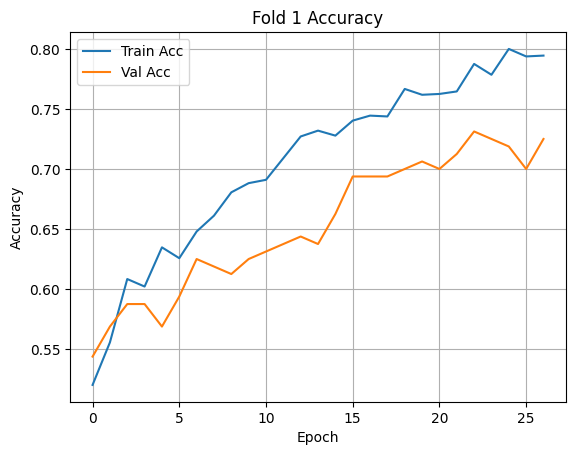

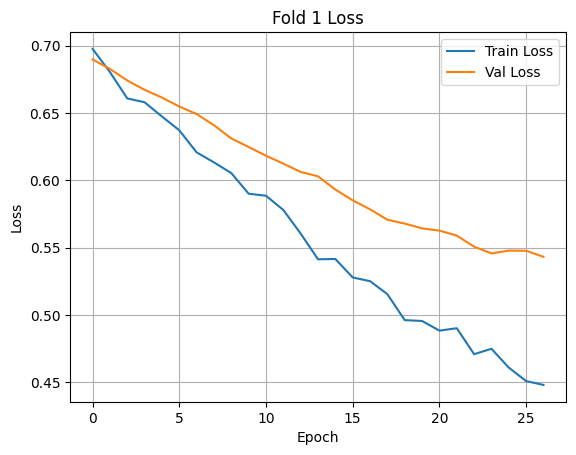

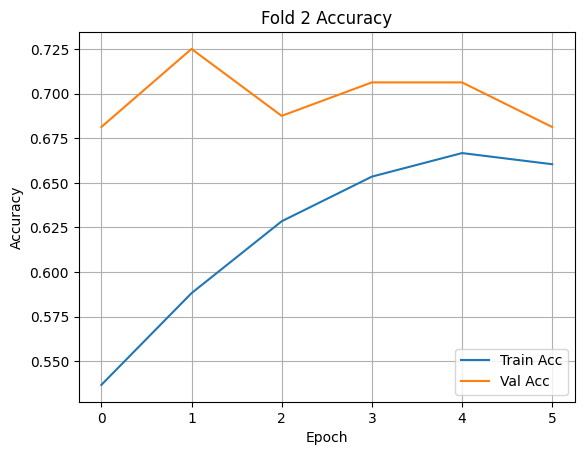

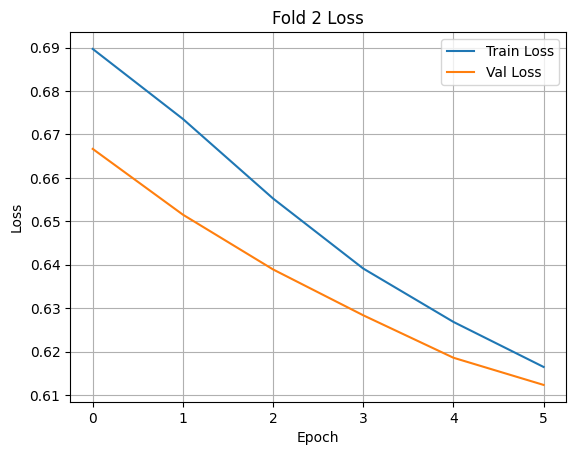

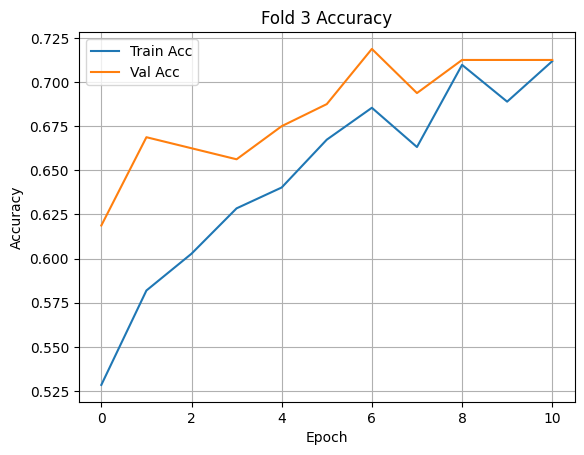

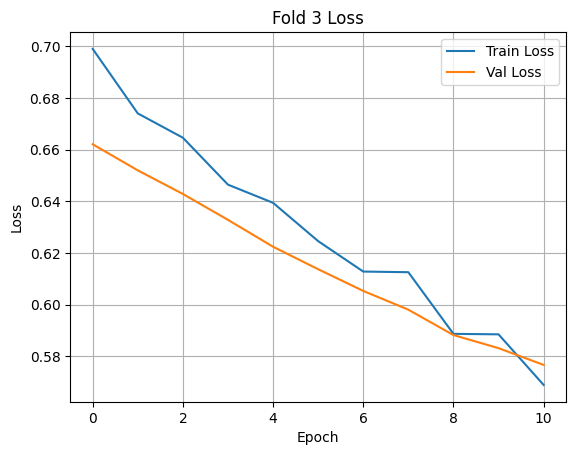

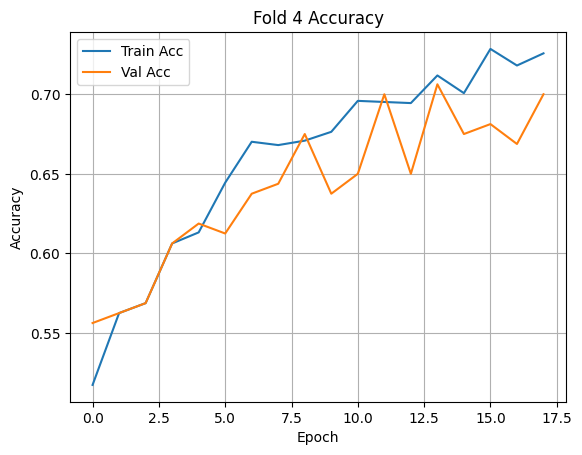

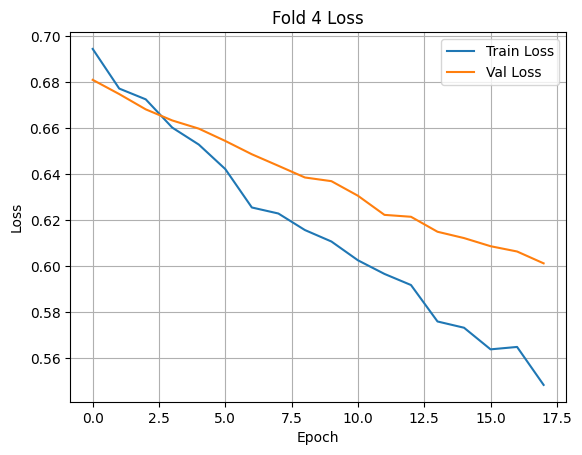

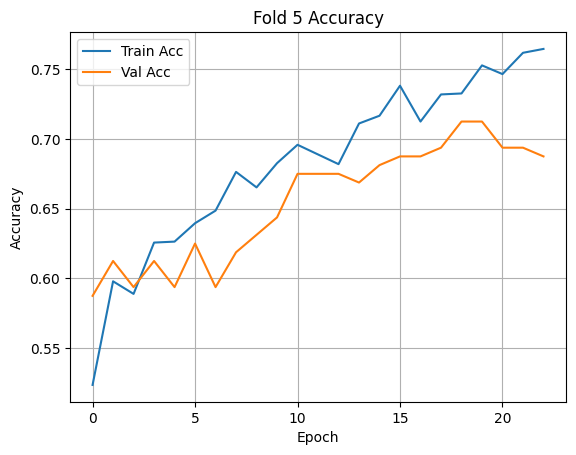

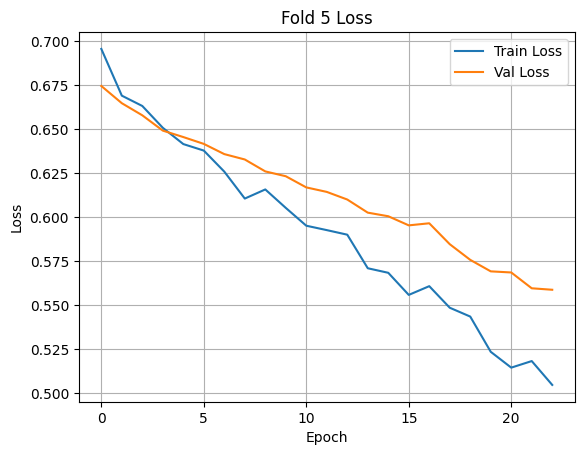

In [29]:
for i, hist in enumerate(all_histories, 1):
    plt.figure()
    plt.plot(hist['accuracy'], label='Train Acc')
    plt.plot(hist['val_accuracy'], label='Val Acc')
    plt.title(f'Fold {i} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title(f'Fold {i} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
